# Analyzing the results of the simulations

For each type of jet and each value of $\theta_c$, the list of the resulting dictionaries is put in a Panda Dataframe.

**Input :** `rick_results_<jettype>_<theta_c>.pkl` where `<jettype>` = `TH` (Top-Hat), `G` (Gaussian) or `PL`(Power-Law), and `<theta_c>` = `005` (0.05 radians) or `015` (0.15 radians).

**Units :** 
- $t_{obs}$ in days,
- $F_\gamma$ in photons/cm$^2$/s.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad
import seaborn as sns


## Top-Hat Jet

In [2]:
file_open = open('all_dico_results_TH.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_TH = pd.DataFrame(configs_open)

In [3]:
results_TH[results_TH['observable'] == 'no']

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,30.059316,off,no,0.000251
1,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,29.478651,off,no,0.001575
2,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,30.381343,off,no,0.000297
4,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,33.576601,off,no,0.000151
5,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,35.401410,off,no,0.000012
...,...,...,...,...,...,...,...
995,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",1.210984,18.114064,on,no,2909.316267
996,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,35.567016,off,no,0.000009
997,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,28.375692,off,no,0.001532
998,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,31.067295,off,no,0.000547


In [4]:
print(len(results_TH[(results_TH['axis'] == 'on') & (results_TH['t_obs'] > 4.)]))
print(len(results_TH[(results_TH['axis'] == 'on') & (results_TH['t_obs'] > 7.)]))

48
39


In [5]:
print(len(results_TH[(results_TH['axis'] == 'off') & (results_TH['t_obs'] > 4.)]))
print(len(results_TH[(results_TH['axis'] == 'off') & (results_TH['t_obs'] > 7.)]))

62
56


## Gaussian Jet
#### $\theta_c$ = 0.05 radians

In [6]:
file_open = open('all_dico_results_G_005.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_G_005 = pd.DataFrame(configs_open)

In [7]:
results_G_005

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.126532,off,no,0.000163
1,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.562465,off,no,0.000897
2,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.428169,off,no,0.000184
3,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",5.482515,13.392466,on,> 4 days,18621.429972
4,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,36.518042,off,no,0.000018
...,...,...,...,...,...,...,...
995,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,28.742242,on,no,0.017110
996,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,36.423515,off,no,0.000007
997,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.448096,off,no,0.000897
998,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.905232,off,no,0.000361


In [8]:
print(len(results_G_005[(results_G_005['axis'] == 'on') & (results_G_005['t_obs'] > 4.)]))
print(len(results_G_005[(results_G_005['axis'] == 'on') & (results_G_005['t_obs'] > 7.)]))

20
13


In [9]:
print(len(results_G_005[(results_G_005['axis'] == 'off') & (results_G_005['t_obs'] > 4.)]))
print(len(results_G_005[(results_G_005['axis'] == 'off') & (results_G_005['t_obs'] > 7.)]))

35
32


#### $\theta_c$ = 0.15 radians

In [10]:
file_open = open('all_dico_results_G_015.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_G_015 = pd.DataFrame(configs_open)

In [11]:
results_G_015

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.181723,off,no,0.000204
1,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.620033,off,no,0.001320
2,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.500141,off,no,0.000248
3,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",24.806739,12.077500,on,> 7 days,40408.054545
4,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,34.293981,off,no,0.000098
...,...,...,...,...,...,...,...
995,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.434091,19.237724,on,no,1030.959010
996,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.659905,off,no,0.000008
997,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,28.497580,off,no,0.001280
998,Gaussian,"{'jetType': 0, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.149148,off,no,0.000442


In [12]:
print(len(results_G_015[(results_G_015['axis'] == 'on') & (results_G_015['t_obs'] > 4.)]))
print(len(results_G_015[(results_G_015['axis'] == 'on') & (results_G_015['t_obs'] > 7.)]))

42
34


In [13]:
print(len(results_G_015[(results_G_015['axis'] == 'off') & (results_G_015['t_obs'] > 4.)]))
print(len(results_G_015[(results_G_015['axis'] == 'off') & (results_G_015['t_obs'] > 7.)]))

55
52


## Power-Law Jet
#### $\theta_c$ = 0.05 radians

In [14]:
file_open = open('all_dico_results_PL_005.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_PL_005 = pd.DataFrame(configs_open)

In [15]:
results_PL_005

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.003913,off,no,0.000173
1,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.414832,off,no,0.000991
2,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.300695,off,no,0.000193
3,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",7.178908,13.043332,on,> 7 days,21657.811039
4,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,36.095083,off,no,0.000028
...,...,...,...,...,...,...,...
995,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.010596,22.450756,on,no,48.685757
996,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,36.347383,off,no,0.000006
997,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.305870,off,no,0.000966
998,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.818572,off,no,0.000374


In [16]:
print(len(results_PL_005[(results_PL_005['axis'] == 'on') & (results_PL_005['t_obs'] > 4.)]))
print(len(results_PL_005[(results_PL_005['axis'] == 'on') & (results_PL_005['t_obs'] > 7.)]))

22
14


In [17]:
print(len(results_PL_005[(results_PL_005['axis'] == 'off') & (results_PL_005['t_obs'] > 4.)]))
print(len(results_PL_005[(results_PL_005['axis'] == 'off') & (results_PL_005['t_obs'] > 7.)]))

39
32


#### $\theta_c$ = 0.15 radians

In [18]:
file_open = open('all_dico_results_PL_015.pkl', 'rb')
configs_open = pickle.load(file_open)
file_open.close()

results_PL_015 = pd.DataFrame(configs_open)

In [19]:
results_PL_015

,jetType,config,t_obs,mag_min,axis,observable,F_gamma
0,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.177832,off,no,0.000204
1,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,29.617288,off,no,0.001323
2,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,30.496374,off,no,0.000248
3,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",24.806739,12.071912,on,> 7 days,40626.288641
4,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,34.177350,off,no,0.000107
...,...,...,...,...,...,...,...
995,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.510491,19.026484,on,no,1248.211916
996,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,35.657667,off,no,0.000008
997,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,28.493242,off,no,0.001283
998,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",0.000000,31.147391,off,no,0.000443


In [20]:
print(len(results_PL_015[(results_PL_015['axis'] == 'on') & (results_PL_015['t_obs'] > 4.)]))
print(len(results_PL_015[(results_PL_015['axis'] == 'on') & (results_PL_015['t_obs'] > 7.)]))

42
35


In [21]:
print(len(results_PL_015[(results_PL_015['axis'] == 'off') & (results_PL_015['t_obs'] > 4.)]))
print(len(results_PL_015[(results_PL_015['axis'] == 'off') & (results_PL_015['t_obs'] > 7.)]))

55
52


## Table of all the results 

| Jet Type | $$\theta_c$$ (rad) | Axis | $$t_{obs}$$ (days) | Number of observable afterlows (/1000) |
|:------------:|:----------:|:------:|:---------------:|:--------------------------------------:|
|**TOP-HAT**   |            | **On** |     **> 4**     |                 48                     |
|              |            |        |     **> 7**     |                 39                     |
|              |            |**Off** |     **> 4**     |                 62                     |
|              |            |        |     **> 7**     |                 56                     |
|              |            |        |                 |                                        |
|**GAUSSIAN**  |  **0.05**  | **On** |     **> 4**     |                 20                     |
|              |            |        |     **> 7**     |                 13                     |
|              |            |**Off** |     **> 4**     |                 35                     |
|              |            |        |     **> 7**     |                 32                     |
|              |  **0.15**  | **On** |     **> 4**     |                 42                     |
|              |            |        |     **> 7**     |                 34                     |
|              |            |**Off** |     **> 4**     |                 55                     |
|              |            |        |     **> 7**     |                 52                     |
|              |            |        |                 |                                        | 
|**POWER-LAW** |  **0.05**  | **On** |     **> 4**     |                 22                     |
|              |            |        |     **> 7**     |                 14                     |
|              |            |**Off** |     **> 4**     |                 39                     |
|              |            |        |     **> 7**     |                 32                     |
|              |  **0.15**  | **On** |     **> 4**     |                 42                     |
|              |            |        |     **> 7**     |                 35                     |
|              |            |**Off** |     **> 4**     |                 55                     |
|              |            |        |     **> 7**     |                 52                     |

In [22]:
# can be saved to parquet file format
results_PL_015.to_parquet('results_PL_015.parquet')

In [23]:
# hack configs function
def hack_configs(results_df):
    config_headers = results_df['config'][0].keys()
    config_dict = dict()
    for key in config_headers:
        config_dict[key] = [results_df['config'][i][key] for i  in range(1000)]
    config_df = pd.DataFrame(config_dict)
    return config_df


In [24]:
# get data frames
configs_TH = hack_configs(results_TH)
configs_G_005 = hack_configs(results_G_005)
configs_G_015 = hack_configs(results_G_015)
configs_PL_005 = hack_configs(results_PL_005)
configs_PL_015 = hack_configs(results_PL_015)

In [25]:
configs_PL_005.head()

,jetType,specType,b,thetaObs,E0,thetaWing,thetaCore,n0,p,epsilon_e,epsilon_B,xi_N,d_L,z
0,4,0,4,1.361997,1.000205e+53,0.107408,0.05,0.012902,2.2,0.1,0.01,1.0,1.005254e+27,0.07
1,4,0,4,0.514569,1.793848e+52,0.099419,0.05,0.002144,2.2,0.1,0.01,1.0,1.465533e+27,0.10
2,4,0,4,0.864864,2.416077e+51,0.102436,0.05,0.078345,2.2,0.1,0.01,1.0,1.005254e+27,0.07
3,4,0,4,0.082420,8.177516e+51,0.227931,0.05,0.324073,2.2,0.1,0.01,1.0,1.005254e+27,0.07
4,4,0,4,0.547648,2.041877e+49,0.229646,0.05,0.014120,2.2,0.1,0.01,1.0,1.465533e+27,0.10


Text(0.5, 1.0, 'PowerLaw 0.05')

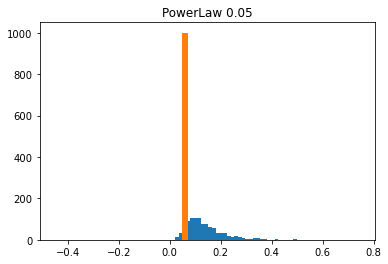

In [26]:
plt.hist(configs_PL_005['thetaWing'], bins=50)
plt.hist(configs_PL_005['thetaCore'], bins=50)
plt.title('PowerLaw 0.05')


Text(0.5, 1.0, 'Top Hat Core')

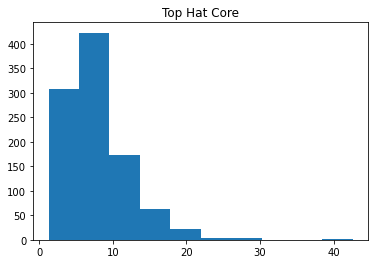

In [27]:
plt.hist(np.degrees(configs_TH['thetaCore']))
plt.title('Top Hat Core')



In [28]:
# join config and results
flat_th = results_TH.join(configs_TH, lsuffix='_name')
flat_G_005 = results_G_005.join(configs_G_005, lsuffix='_name')
flat_G_015 = results_G_015.join(configs_G_015, lsuffix='_name')
flat_PL_005 = results_PL_005.join(configs_PL_005, lsuffix='_name')
flat_PL_015 = results_PL_015.join(configs_PL_015, lsuffix='_name')


In [29]:
# merge all results
mrs = pd.concat([flat_th, flat_G_005, flat_G_015, flat_PL_005, flat_PL_015])
mrs.size

105000

In [30]:
# add tweaked quantities
def add_vars(df):    
    df['log_E0'] = np.log10(df['E0'])
    df['log_tobs'] = np.log10(df['t_obs'])
    df['log_tobs'] = df['log_tobs'].replace(-np.inf, 0)
    df['log_tobs_norm'] = df['log_tobs']/df['log_E0']
    df['thetaObs_deg'] = np.degrees(df['thetaObs'])
    df['thetaCore_deg'] = np.degrees(df['thetaCore'])
    df['thetaWing_deg'] = np.degrees(df['thetaWing'])
    df.head()
    return df


In [38]:
mrs_ext = add_vars(mrs)
mrs.head()

/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,jetType_name,config,t_obs,mag_min,axis,observable,F_gamma,jetType,specType,b,...,epsilon_B,xi_N,d_L,z,log_E0,log_tobs,log_tobs_norm,thetaObs_deg,thetaCore_deg,thetaWing_deg
0,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,30.059316,off,no,0.000251,-1,0,4,...,0.01,1.0,1.005254e+27,0.07,53.000089,0.000000,0.000000,78.036685,6.154043,6.154043
1,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,29.478651,off,no,0.001575,-1,0,4,...,0.01,1.0,1.465533e+27,0.10,52.253786,0.000000,0.000000,29.482651,5.696288,5.696288
2,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,30.381343,off,no,0.000297,-1,0,4,...,0.01,1.0,1.005254e+27,0.07,51.383111,0.000000,0.000000,49.553053,5.869143,5.869143
3,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",42.529652,11.915615,on,> 7 days,44253.309307,-1,0,4,...,0.01,1.0,1.005254e+27,0.07,51.912621,1.628692,0.031374,4.722345,13.059488,13.059488
4,TopHat,"{'jetType': -1, 'specType': 0, 'b': 4, 'thetaO...",0.000000,33.576601,off,no,0.000151,-1,0,4,...,0.01,1.0,1.465533e+27,0.10,49.310030,0.000000,0.000000,31.377901,13.157744,13.157744


In [43]:
# keep only good t_obs
good_mrs = mrs[(mrs['t_obs']>0) & (mrs['t_obs']<300)]

In [52]:
def show_scatter(ax, df, tag):
    _thetaObs = ax[0][0].scatter(df['thetaObs_deg'], df['t_obs'])
    ax[0][0].set_xlabel("thetaObs")
    ax[0][0].set_ylabel("t_obs")
    _thetaCore = ax[0][1].scatter(df['thetaCore_deg'], df['t_obs'])
    ax[0][1].set_xlabel("thetaCore")
    ax[0][1].set_ylabel("t_obs")
    _thetaWing = ax[1][0].scatter(df['thetaWing_deg'], df['t_obs'])
    ax[1][0].set_xlabel("thetaWing")
    ax[1][0].set_ylabel("t_obs")
    _logE0 = ax[1][1].scatter(df['log_E0'], df['t_obs'])
    ax[1][1].set_xlabel("log_E0")
    ax[1][1].set_ylabel("t_obs")


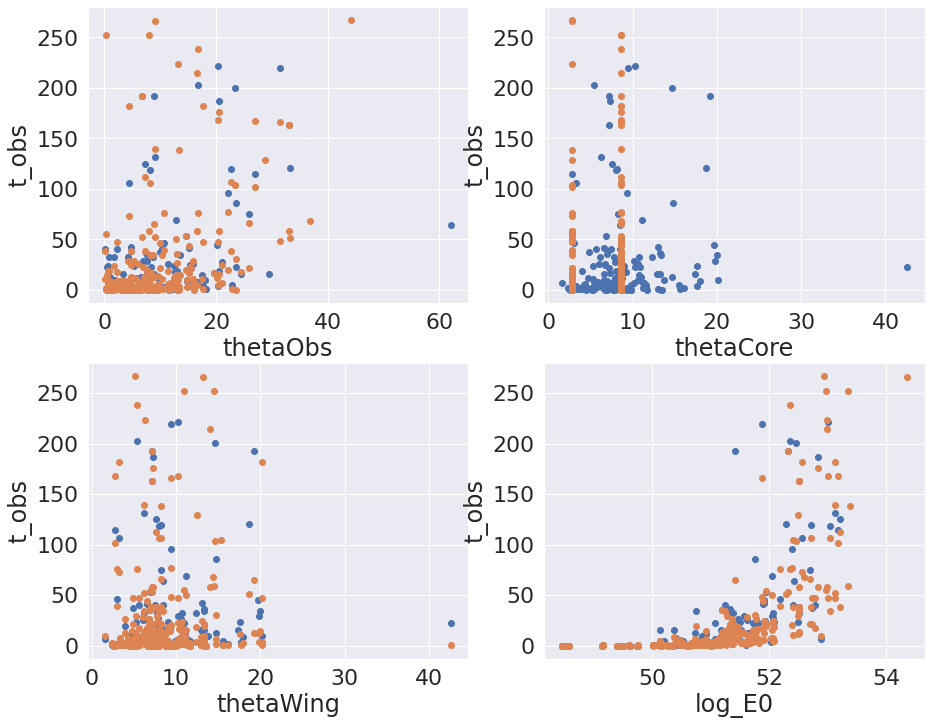

In [55]:
plt.rcParams["figure.figsize"] = [15, 12]
fig, ax = plt.subplots(2, 2)
show_scatter(ax, good_mrs[good_mrs['jetType']==-1], 'TopHat')
show_scatter(ax, good_mrs[good_mrs['jetType']==0], 'Gaussian')


In [34]:
flat_th_ext = add_vars(flat_th)
flat_G_005_ext = add_vars(flat_G_005)
flat_G_015_ext = add_vars(flat_G_015)
flat_PL_005_ext = add_vars(flat_PL_005)
flat_PL_015_ext = add_vars(flat_PL_015)


/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log1

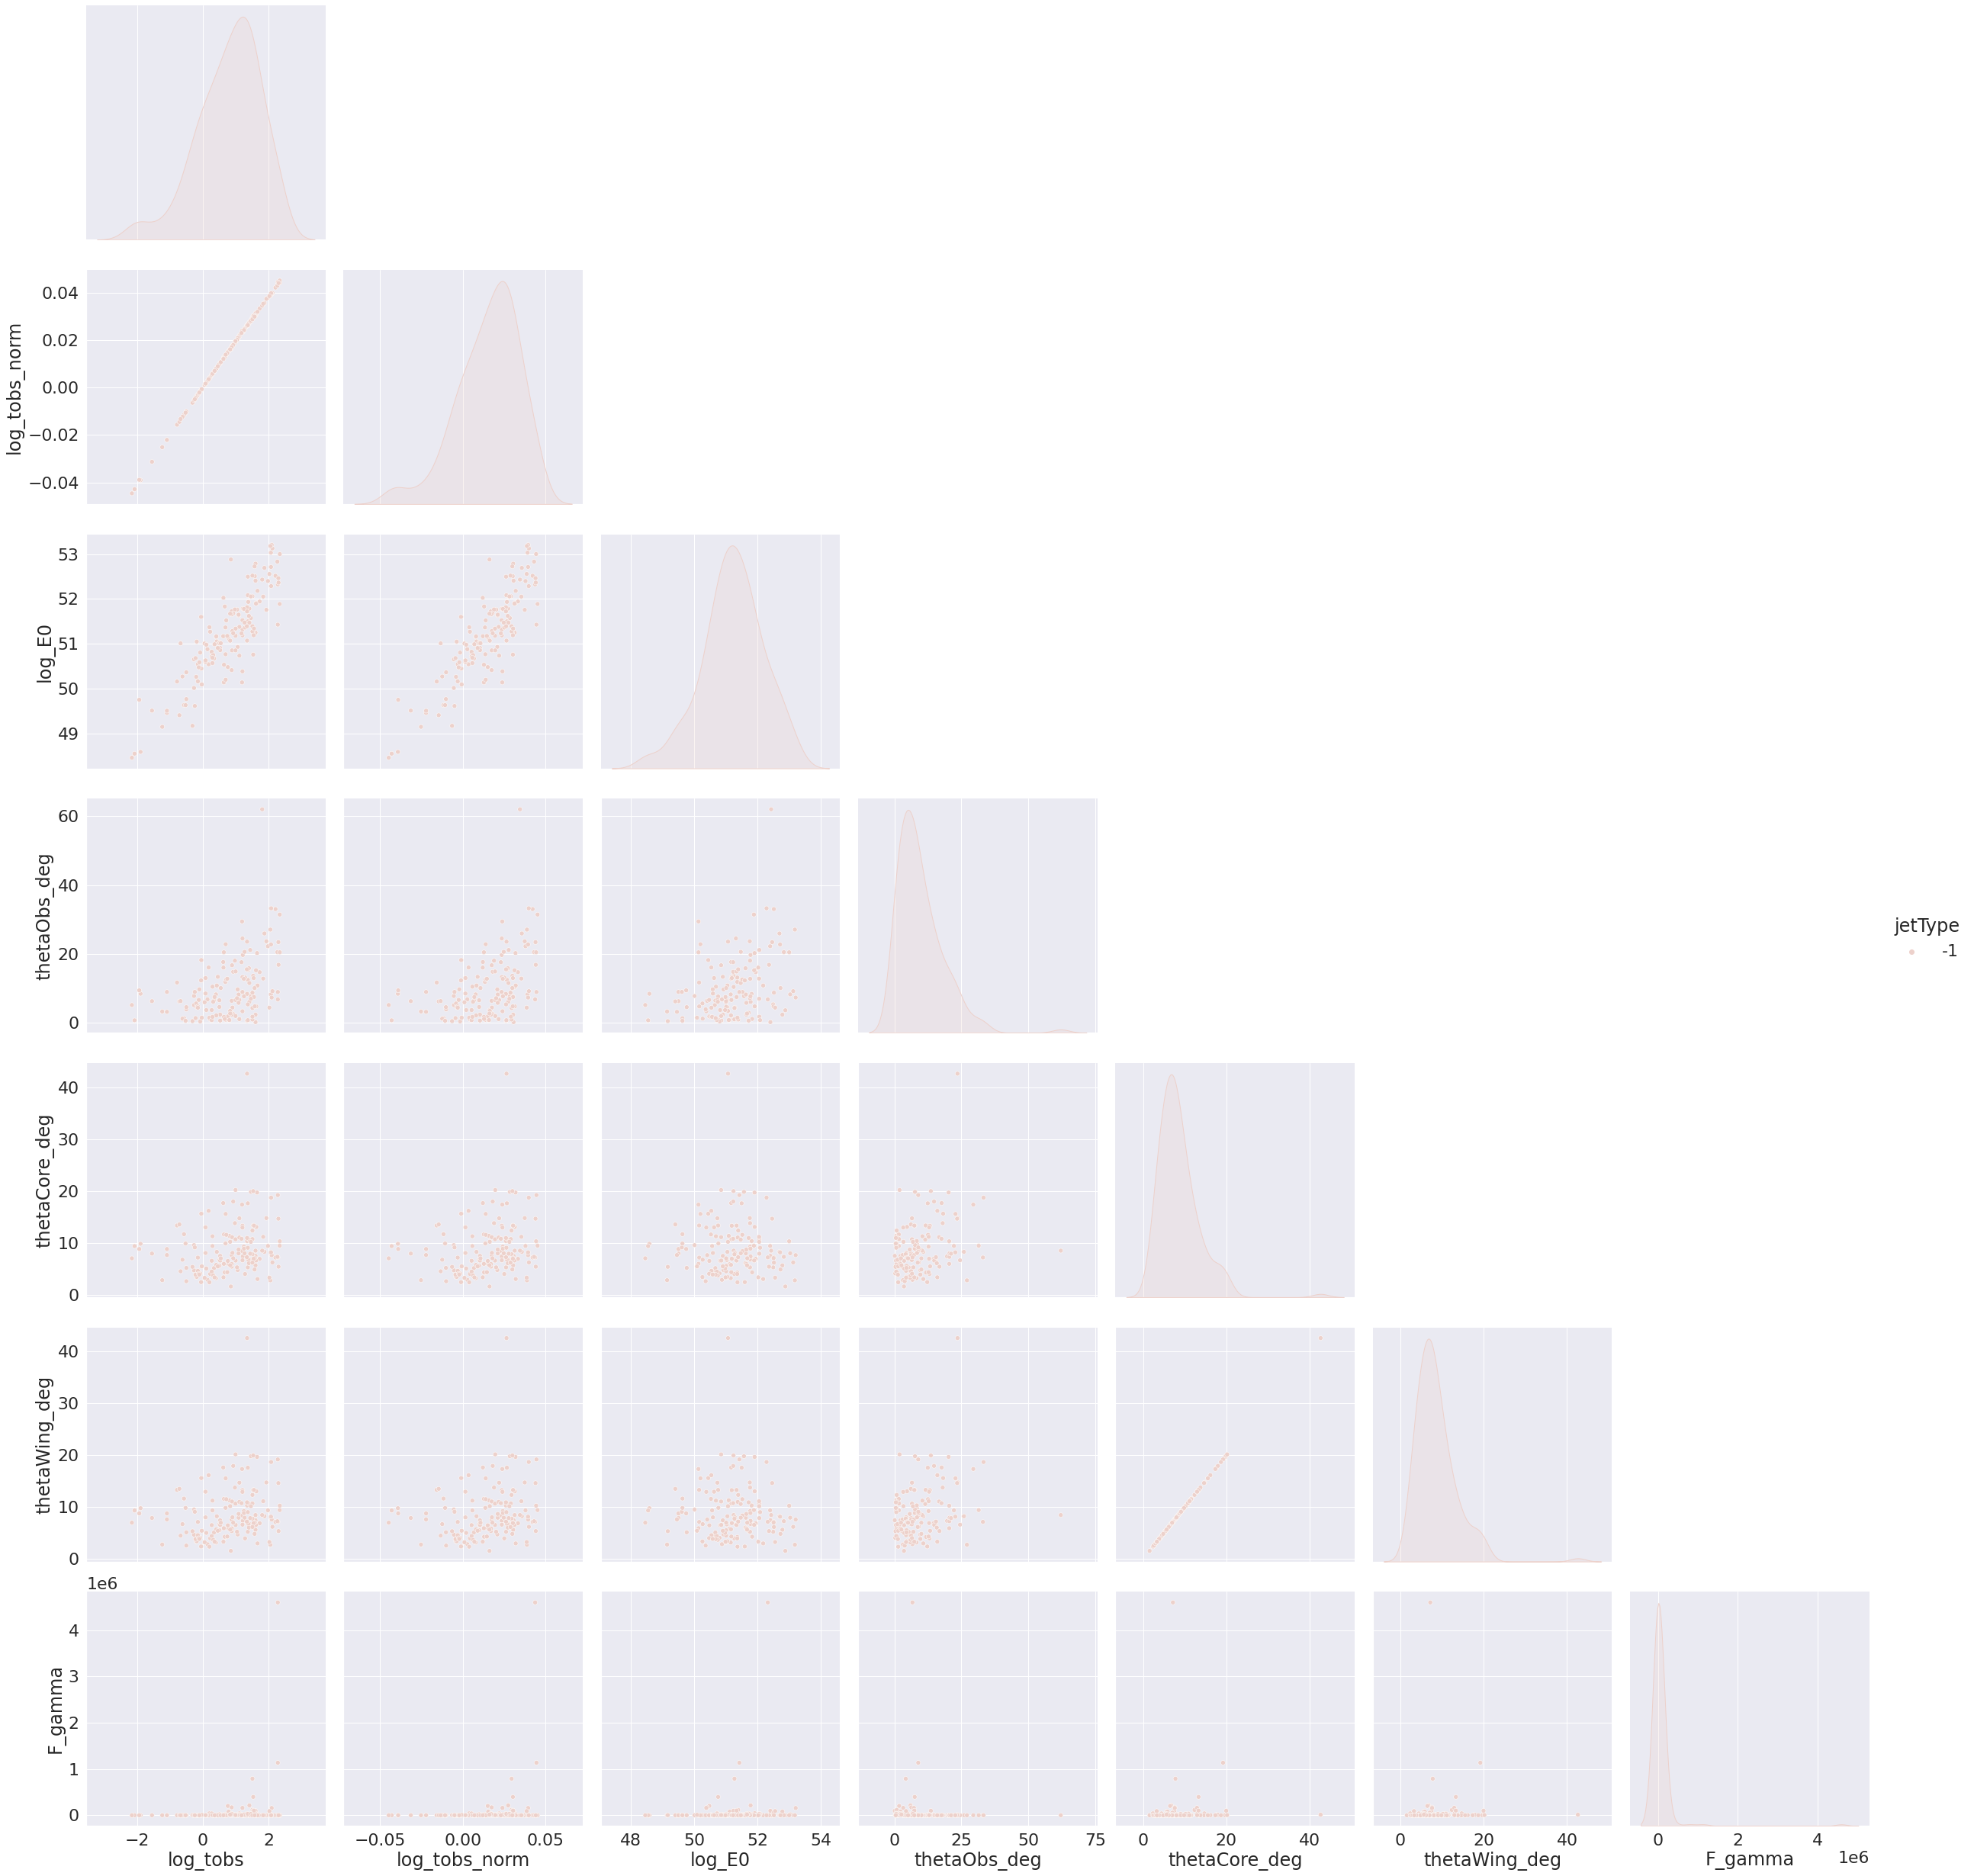

In [39]:
sns.set_theme(style="ticks")
sns.set(font_scale=2)
#vars_to_plot = ['t_obs', 'thetaObs', 'E0_53'] #'mag_min', 'F_gamma', 'jetType', 'E0', , 'thetaWing',
                # 'thetaCore', 'thetaO''n0', 'z']
vars_to_plot = ['log_tobs', 'log_tobs_norm', 'log_E0', 'thetaObs_deg', 'thetaCore_deg', 'thetaWing_deg', 'F_gamma']
#vars_to_plot = ['t_obs', 'E0', 'thetaObs', 'thetaCore', 'thetaWing']

sns.pairplot(flat_th_ext[(flat_th_ext['t_obs']>0) & (flat_th_ext['t_obs']<300)], vars=vars_to_plot, corner=True, hue="jetType", height=5)


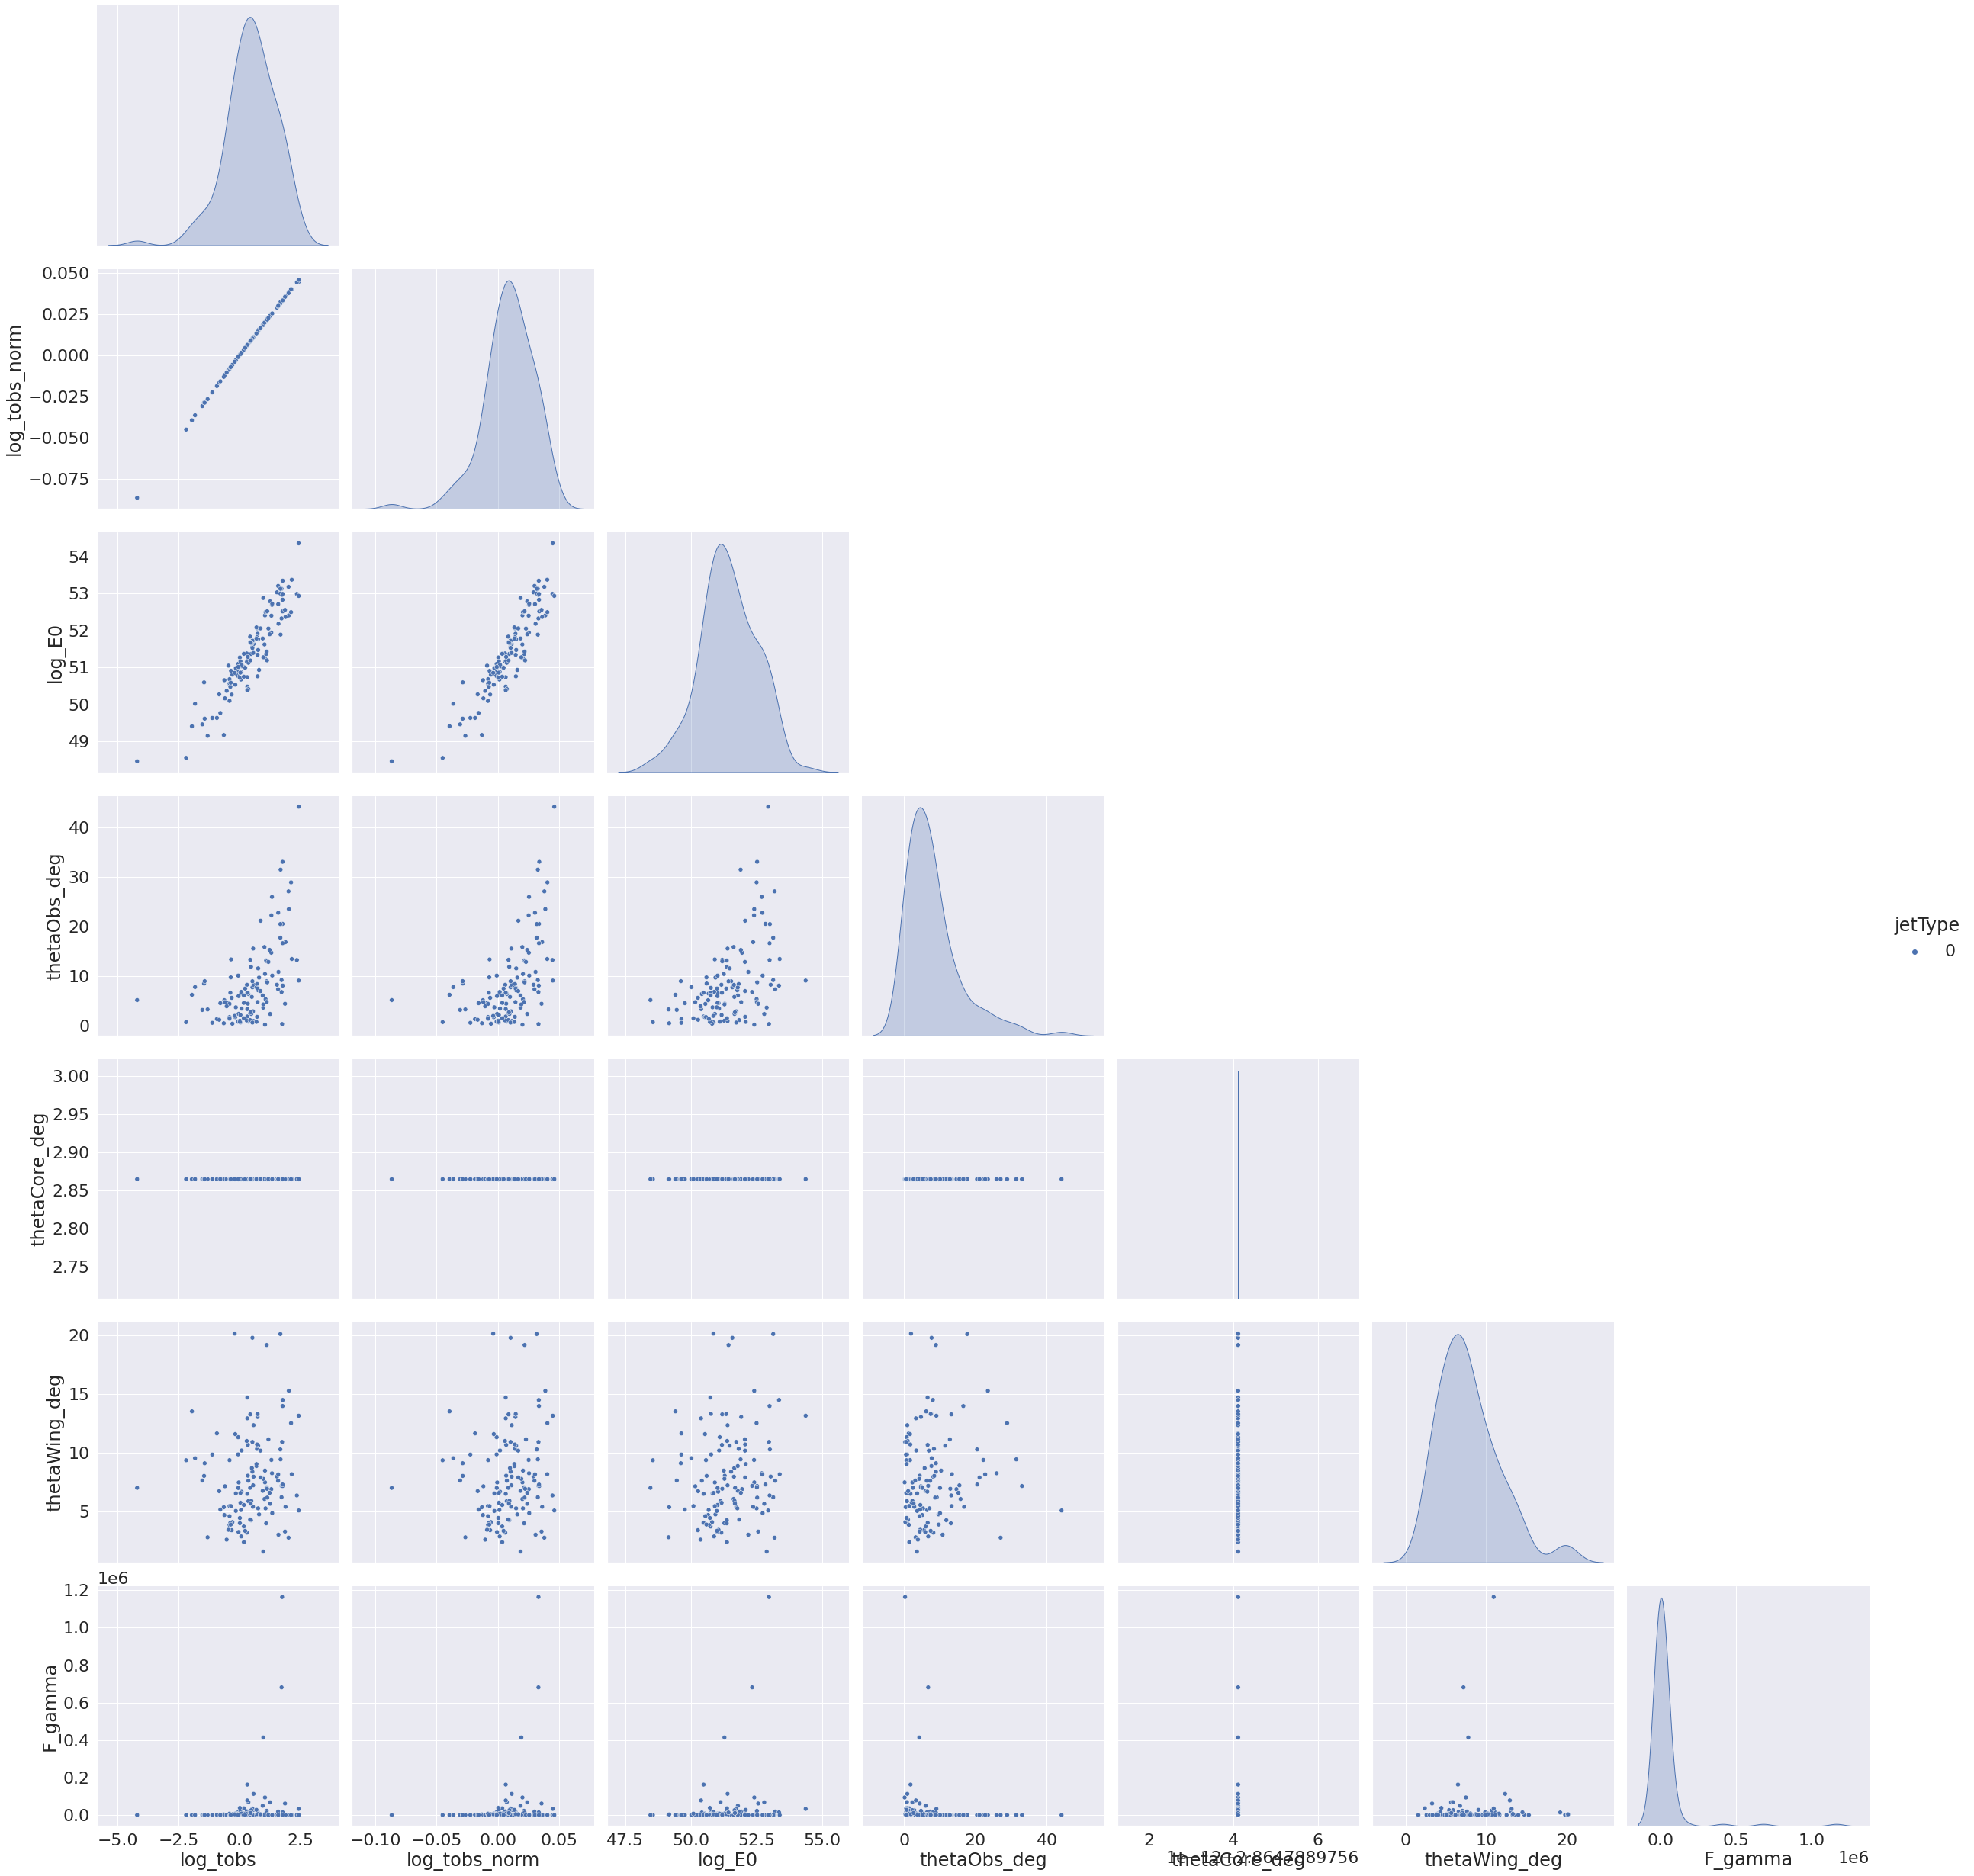

In [40]:
sns.pairplot(flat_G_005_ext[(flat_G_005_ext['t_obs']>0) & (flat_G_005_ext['t_obs']<300)], vars=vars_to_plot, corner=True, hue="jetType", height=5)


<AxesSubplot:>

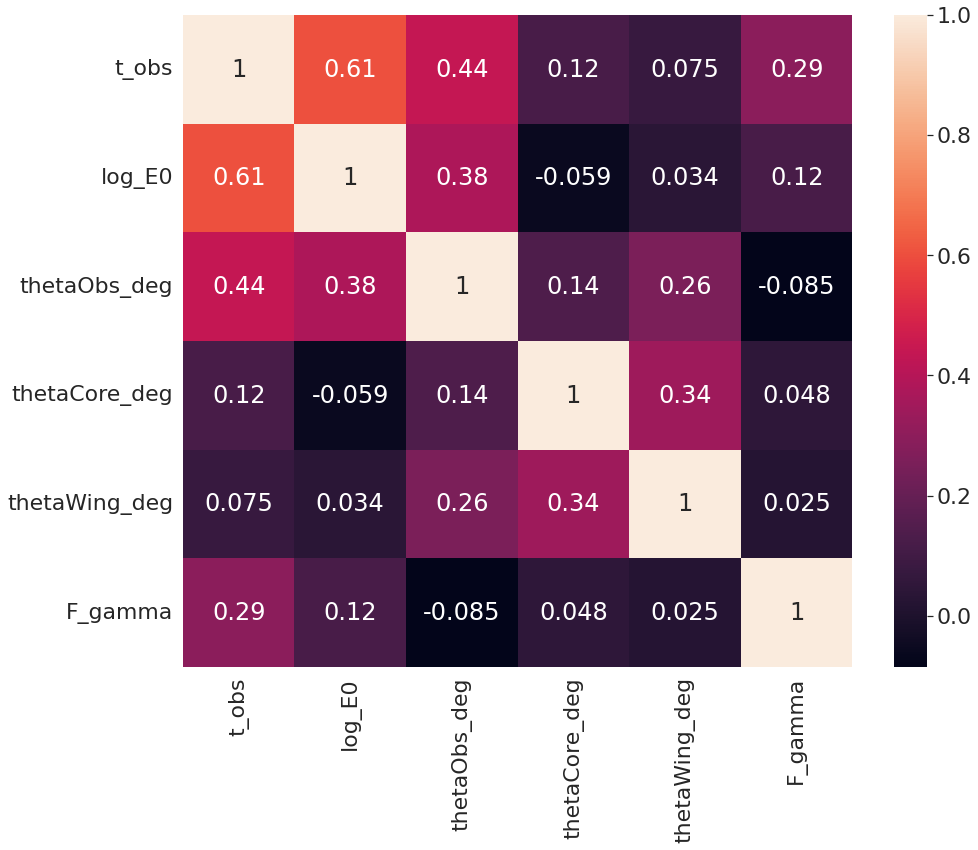

In [57]:
reduced_mrs = good_mrs[['t_obs', 'log_E0', 'thetaObs_deg', 'thetaCore_deg', 'thetaWing_deg', 'F_gamma']]
corrMatrix = reduced_mrs.corr()
sns.heatmap(corrMatrix, annot=True)


<AxesSubplot:>

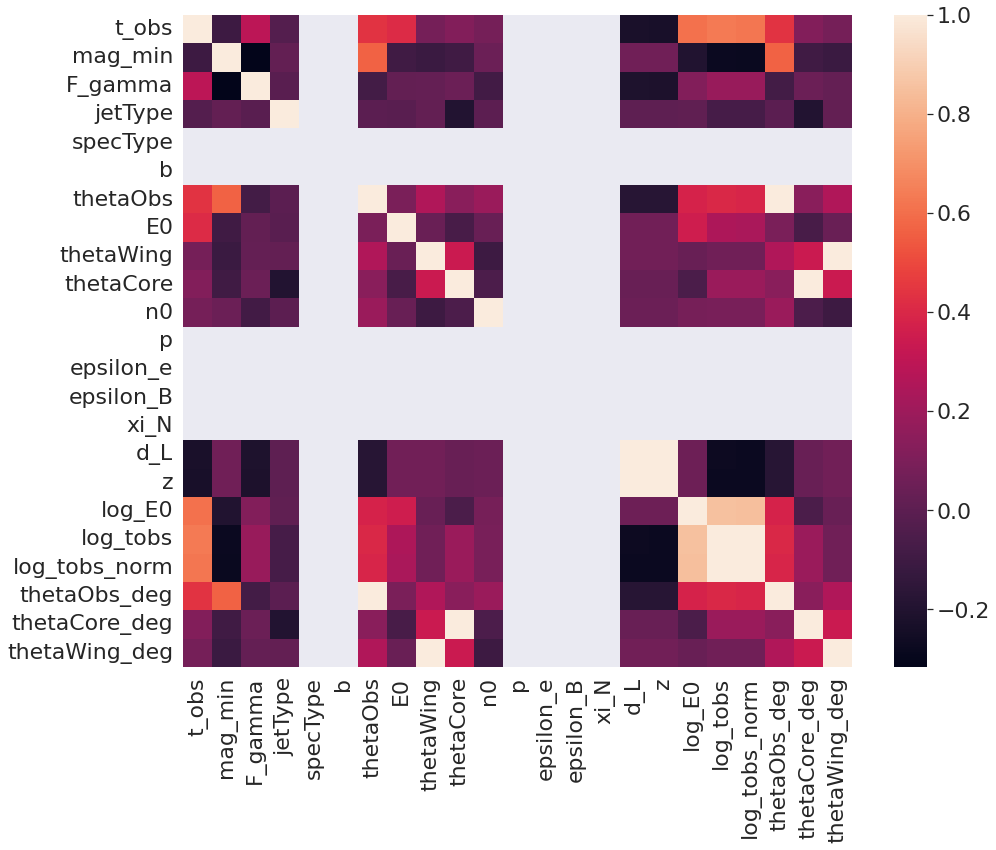

In [59]:
full_corrMatrix = good_mrs.corr()
sns.heatmap(full_corrMatrix, annot=False)


<AxesSubplot:>

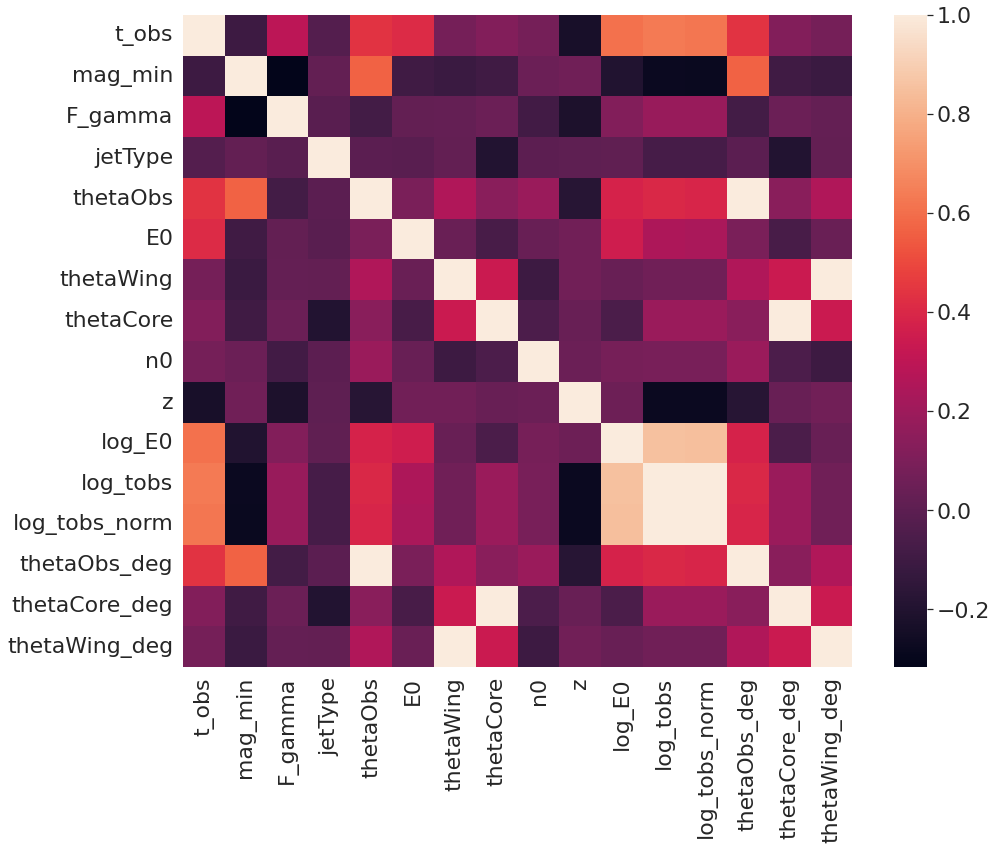

In [82]:
keys_to_remove = ['b', 'specType', 'p', 'epsilon_e', 'epsilon_B', 'xi_N', 'd_L']
my_keys = [x for x in list(good_mrs.keys()) if x not in keys_to_remove]
my_mrs = good_mrs[my_keys]
my_corrMatrix = my_mrs.corr()
sns.heatmap(my_corrMatrix, annot=False)
